# Détection d'Alzheimer — Compétition M2 BDIA DL Project 2025

Ce notebook présente ma démarche pour résoudre la compétition Kaggle :  
**"M-2 BDIA DL Project 2025"**, dont l’objectif est de prédire les stades de la maladie d’Alzheimer à partir de données [...].

Dans ce notebook, nous allons :
- Explorer les données fournies
- Prétraiter les features
- Entraîner plusieurs modèles de Deep Learning
- Évaluer et comparer leurs performances
- Générer une soumission au format demandé



In [1]:
# ============================
# 📦 IMPORTS
# ============================

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Preprocessing & Evaluation
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.decomposition import PCA
from sklearn.utils.class_weight import compute_class_weight

# Oversampling (handling imbalanced datasets)
from imblearn.over_sampling import SMOTE

# Deep Learning (TensorFlow / Keras)
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, LayerNormalization, Add,
    BatchNormalization, GaussianNoise, Conv1D, Reshape,
    GlobalAveragePooling1D
)
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l1

# Other utilities
from collections import Counter

# ============================
# 🔧 RANDOM SEED (Reproducibility)
# ============================

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


# Importation des données

Dans cette section, on charge les fichiers `data.csv`, `test.csv`, etc., et on vérifie leurs dimensions et types.


In [2]:
# Load the training data
train_data = pd.read_csv('../data/data.csv')
# Load the test data
test_data = pd.read_csv('../data/test.csv',sep=';')

# Analyse Exploratoire

- Visualisation des distributions
- Recherche de valeurs manquantes
- Analyse des corrélations
- Identification des patterns potentiels

Cette étape permet de mieux comprendre la structure des données avant d’entraîner un modèle.


In [3]:
# Display Train basic information
print(f"\nDataset Shape: {train_data.shape}")
print(f"Number of features: {train_data.shape[1] - 1}")
print("\nFirst few rows:")
print(train_data.head())

# Check for missing values
print(f"\nMissing values: {train_data.isnull().sum().sum()}")


Dataset Shape: (104, 451)
Number of features: 450

First few rows:
   air_time1  disp_index1  gmrt_in_air1  gmrt_on_paper1  max_x_extension1  \
0       4860     0.000013    236.876312      308.575985              3171   
1       2005     0.000010    174.435893      158.661271              1798   
2      12960     0.000019    154.094876       66.137920              1335   
3       7870     0.000012    102.981366       79.647541              1420   
4       3590     0.000009    241.464110      143.991636              1557   

   max_y_extension1  mean_acc_in_air1  mean_acc_on_paper1  mean_gmrt1  \
0              7348          0.277021            0.214148  272.726149   
1              5962          0.209676            0.125318  166.548582   
2              9809          0.303533            0.168974  110.116398   
3              6142          0.320674            0.156004   91.314453   
4              6218          0.220933            0.163247  192.727873   

   mean_jerk_in_air1  ...  mea

In [4]:
# Display basic information
print(f"\nDataset Shape: {test_data.shape}")
print(f"Number of features: {test_data.shape[1] }")
print("\nFirst few rows:")
print(test_data.head())

# Check for missing values
print(f"\nMissing values: {test_data.isnull().sum().sum()}")


Dataset Shape: (70, 450)
Number of features: 450

First few rows:
   air_time1  disp_index1  gmrt_in_air1  gmrt_on_paper1  max_x_extension1  \
0       2130     0.000010    369.403342      183.193104              1756   
1       3525     0.000010    126.323599      139.596243              1046   
2       4695     0.000007    170.640009      141.200539              1715   
3       2635     0.000007    261.166647      147.334293              2099   
4       5705     0.000011    331.233476      156.489551              1039   

   max_y_extension1  mean_acc_in_air1  mean_acc_on_paper1  mean_gmrt1  \
0              8159          0.556879            0.164502  276.298223   
1              6118          0.225717            0.161174  132.959921   
2              5983          0.182334            0.144740  155.920274   
3              3936          0.620047            0.149459  204.250470   
4              7637          1.373276            0.140836  243.861514   

   mean_jerk_in_air1  ...  mean

In [5]:
# Identify columns

target_col = train_data.columns[-1]
feature_cols = train_data.columns[:-1]


print(f"Target Column: {target_col}")
print(f"Number of Feature Columns: {len(feature_cols)}")

Target Column: class
Number of Feature Columns: 450


In [6]:
# Class distribution
print("\n--- Class Distribution ---")
class_dist = train_data[target_col].value_counts()
print(class_dist)
print(f"\nClass Balance:")
print(f"Healthy (0): {class_dist[0]} ({class_dist[0]/len(train_data)*100:.1f}%)")
print(f"Patient (1): {class_dist[1]} ({class_dist[1]/len(train_data)*100:.1f}%)")


--- Class Distribution ---
class
1    65
0    39
Name: count, dtype: int64

Class Balance:
Healthy (0): 39 (37.5%)
Patient (1): 65 (62.5%)


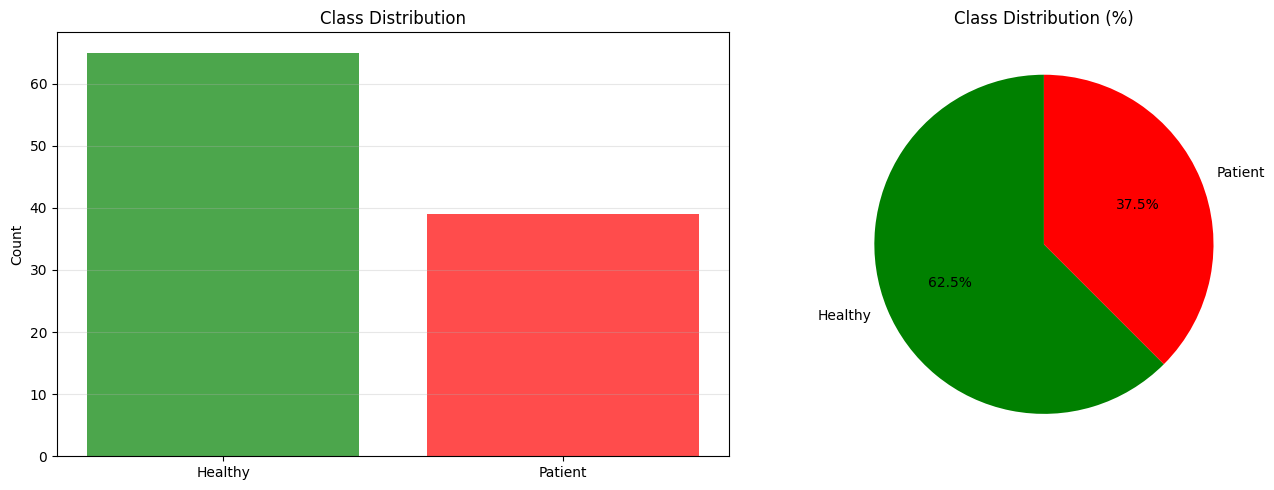

In [7]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(['Healthy', 'Patient'], class_dist.values, color=['green', 'red'], alpha=0.7)
axes[0].set_ylabel('Count')
axes[0].set_title('Class Distribution')
axes[0].grid(axis='y', alpha=0.3)

axes[1].pie(class_dist.values, labels=['Healthy', 'Patient'], autopct='%1.1f%%',
            colors=['green', 'red'], startangle=90)
axes[1].set_title('Class Distribution (%)')

plt.tight_layout()
plt.show()


In [8]:
# Basic statistics
print("\n--- Feature Statistics ---")
X = train_data[feature_cols]
y = train_data[target_col]

print(f"Feature value ranges:")
print(f"Min: {X.min().min():.4f}")
print(f"Max: {X.max().max():.4f}")
print(f"Mean: {X.mean().mean():.4f}")
print(f"Std: {X.std().std():.4f}")



--- Feature Statistics ---
Feature value ranges:
Min: 0.0000
Max: 9206165.0000
Mean: 14044.2150
Std: 136543.5090


In [9]:
# Check for constant features
constant_features = [col for col in feature_cols if X[col].nunique() == 1]
print(f"\nConstant features: {len(constant_features)}")


Constant features: 0


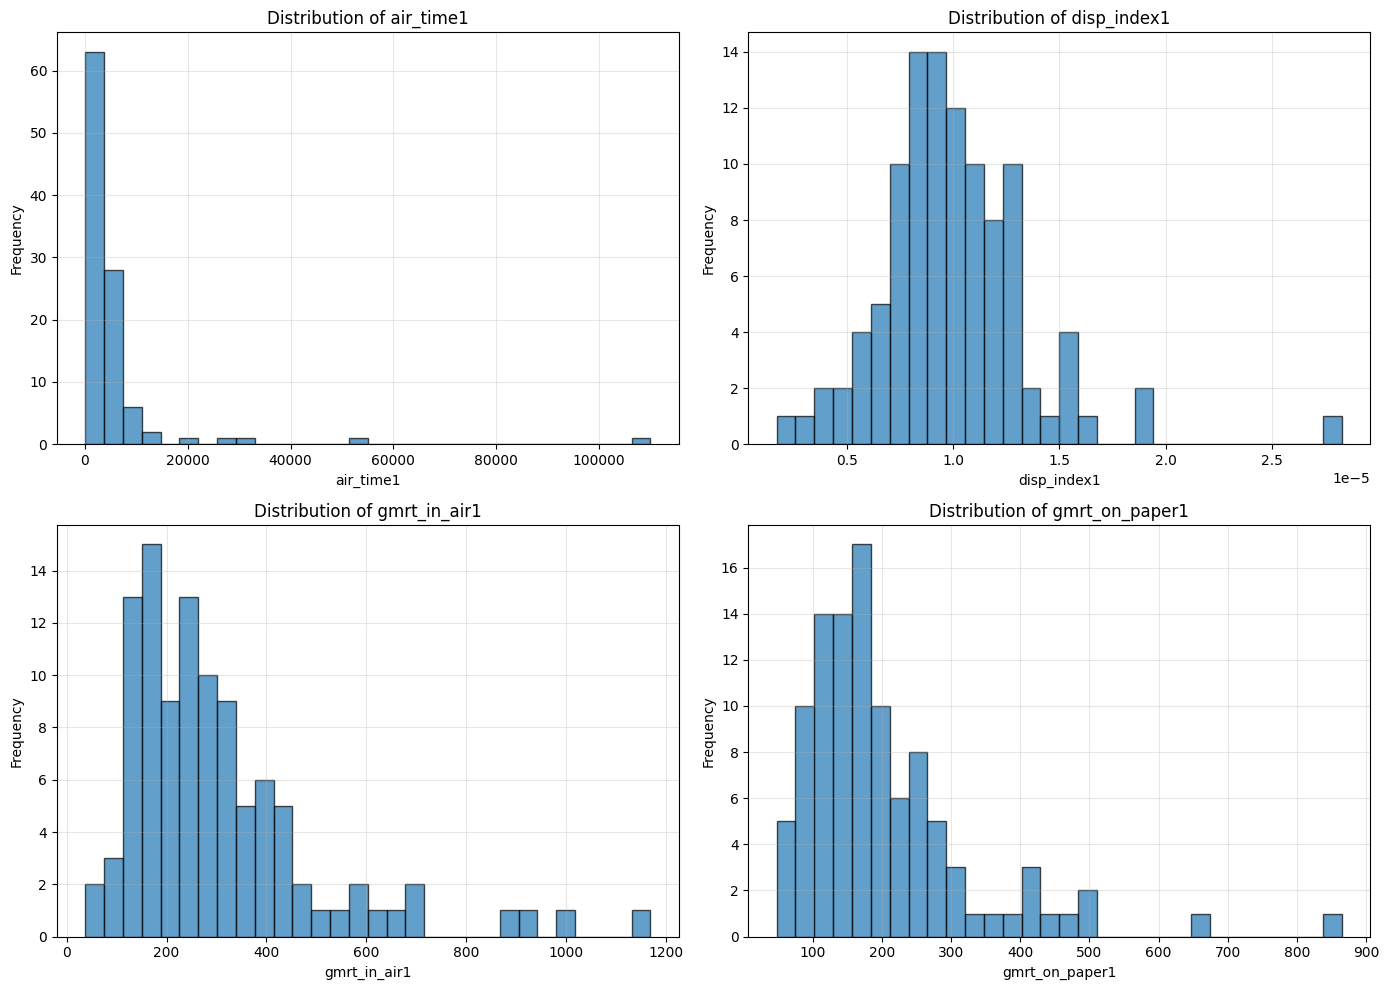

In [10]:
# Visualize feature distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sample_features = feature_cols[:4]

for idx, feat in enumerate(sample_features):
    ax = axes[idx//2, idx%2]
    ax.hist(X[feat], bins=30, alpha=0.7, edgecolor='black')
    ax.set_xlabel(feat)
    ax.set_ylabel('Frequency')
    ax.set_title(f'Distribution of {feat}')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# Correlation analysis
print("\n--- High Correlation Features ---")
correlation_matrix = X.corr().abs()
upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

# Find highly correlated features (>0.95)
high_corr_features = [column for column in upper_triangle.columns
                      if any(upper_triangle[column] > 0.95)]
print(f"Features with correlation > 0.95: {len(high_corr_features)}")



--- High Correlation Features ---
Features with correlation > 0.95: 83



--- Feature Importance (Univariate) ---

Top 20 Features by F-statistic:
                  Feature      Score
116            mean_gmrt7  41.496427
110          gmrt_in_air7  35.725704
379          disp_index22  34.849001
296           mean_gmrt17  33.433766
299   mean_speed_in_air17  33.277519
119    mean_speed_in_air7  33.166669
443   mean_speed_in_air25  31.837156
53            total_time3  31.440066
294     mean_acc_in_air17  30.256202
297    mean_jerk_in_air17  29.763732
111        gmrt_on_paper7  29.720822
397          disp_index23  28.618039
290         gmrt_in_air17  28.224168
434         gmrt_in_air25  26.406411
233          total_time13  24.720615
440           mean_gmrt25  24.047104
407   mean_speed_in_air23  23.747852
291       gmrt_on_paper17  23.521828
120  mean_speed_on_paper7  22.666496
438     mean_acc_in_air25  22.241049


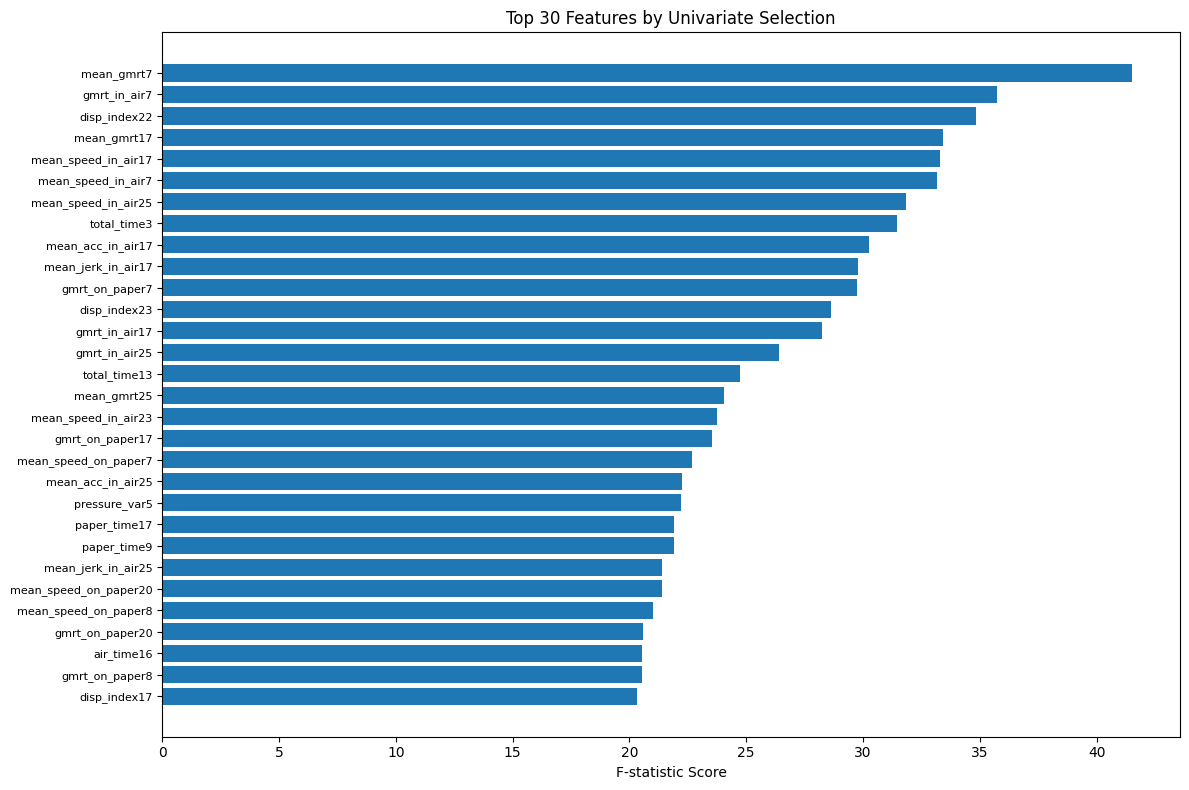

In [12]:
# Feature importance using univariate selection
print("\n--- Feature Importance (Univariate) ---")
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X, y)

# Get feature scores
feature_scores = pd.DataFrame({
    'Feature': feature_cols,
    'Score': selector.scores_
}).sort_values('Score', ascending=False)

print("\nTop 20 Features by F-statistic:")
print(feature_scores.head(20))

# Visualize top features
plt.figure(figsize=(12, 8))
top_n = 30
top_features = feature_scores.head(top_n)
plt.barh(range(top_n), top_features['Score'].values)
plt.yticks(range(top_n), top_features['Feature'].values, fontsize=8)
plt.xlabel('F-statistic Score')
plt.title(f'Top {top_n} Features by Univariate Selection')
plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

# Prétraitement

Ici, je nettoie et prépare les données :

- Normalisation / Standardisation
- Encodage des variables
- Séparation train/validation
- Création éventuelle de nouvelles features

Section 2 - SMOTE (rééquilibrage)

In [13]:
RANDOM_SEED = 42

smote = SMOTE(random_state=RANDOM_SEED)
X, y = smote.fit_resample(X, y)
print('After SMOTE shape:', X.shape)
print('Class balance after SMOTE:', Counter(y))


After SMOTE shape: (130, 450)
Class balance after SMOTE: Counter({1: 65, 0: 65})


In [14]:
# Split data
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
X_test=test_data.copy()

print(f"\nTraining set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")


Training set: (104, 450)
Validation set: (26, 450)


# DEEP LEARNING MODEL to determine the most important features 

In [15]:

def get_feature_importance_sparse(X_train, y_train, X_val, y_val, k=20, l1_strength=0.01):
    n_features = X_train.shape[1]

    # ----- Build sparse model -----
    inp = Input(shape=(n_features,))

    # L1 forcing sparsity on features
    x = Dense(
        64,
        activation='relu',
        kernel_regularizer=l1(l1_strength)
    )(inp)

    x = Dense(32, activation='relu')(x)
    out = Dense(1, activation='sigmoid')(x)

    model = Model(inp, out)

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["AUC"]
    )

    es = EarlyStopping(
        patience=10,
        restore_best_weights=True,
        monitor="val_AUC",
        mode="max"
    )

    # ----- Train -----
    model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=32,
        callbacks=[es],
        verbose=0
    )

    # ----- Feature importance = abs(weights of first layer) -----
    first_layer_weights = model.layers[1].get_weights()[0]  # shape (n_features, 64)

    # Aggregate weights across neurons (L1 importance)
    importance = np.mean(np.abs(first_layer_weights), axis=1)

    # Get top-k features
    top_k_idx = np.argsort(-importance)[:k]
    top_k_vals = importance[top_k_idx]

    # Return a dict {feature_index: importance_value}
    importance_dict = {
        int(idx): float(val)
        for idx, val in zip(top_k_idx, top_k_vals)
    }

    return importance_dict


#Standar Scaler


In [16]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)


In [17]:
X_test_scaled = scaler.transform(X_test)

In [18]:
pd.DataFrame(X_train_scaled).head()

,0,1,2,3,4,5,6,7,8,9,...,440,441,442,443,444,445,446,447,448,449
0,0.009340,0.636626,-0.110969,0.027065,-0.283906,0.772626,0.733234,-0.027759,-0.067497,0.871690,...,-0.055864,-0.135728,-1.260757,0.168400,-0.505178,-0.505227,-0.040757,-0.823409,0.721155,-0.195186
1,-0.257993,0.001734,-0.111491,0.020018,0.001038,-0.403461,-0.626683,-0.357255,-0.070785,-0.560139,...,0.787149,0.940006,-0.508772,0.288633,0.615390,-0.938170,-0.298567,0.995276,-1.244262,-0.198367
2,-0.058484,0.117724,-0.834274,-0.512142,-0.363657,0.095298,-0.202422,-0.808929,-0.803858,-0.125090,...,-1.251547,-0.974927,-1.150726,-0.876513,-1.436759,2.564734,2.059297,0.256363,2.207026,0.050546
3,-0.038665,0.392437,-0.788542,-0.622800,-0.069575,0.587387,-0.544464,-0.650258,-0.817256,-0.482561,...,-1.770981,-1.800909,-0.134233,-1.561830,-2.104652,1.738206,-0.088399,-0.145946,0.592185,-0.147947
4,-0.343434,-0.312659,-0.151463,-0.677946,-0.833857,-1.081814,-0.583056,-0.989031,-0.388238,-0.588238,...,0.622811,0.201580,2.800958,1.234220,0.650204,0.951037,-0.503836,0.444908,1.215023,0.806407


In [19]:
pd.DataFrame(X_test_scaled).head()

,0,1,2,3,4,5,6,7,8,9,...,440,441,442,443,444,445,446,447,448,449
0,-0.239496,0.148248,0.199178,-0.195457,-0.197509,0.411385,0.326825,-0.264803,0.060311,0.287969,...,-0.996826,-0.665124,-0.102885,-0.152991,-1.656972,1.541414,1.445125,-0.323060,1.188805,0.021600
1,-0.116619,0.117724,-1.007745,-0.566121,-0.787335,-0.635907,-0.536163,-0.316707,-0.949254,-0.560220,...,-1.022478,-1.415049,-0.264546,-1.167093,-0.359543,0.439377,0.866072,0.315937,-0.069836,-0.021809
2,-0.013561,-0.773566,-0.787708,-0.552481,-0.231569,-0.705179,-0.649216,-0.573042,-0.787539,-0.533082,...,-0.545399,-0.203012,0.272475,-0.541570,-0.676043,0.045792,-0.405013,-0.001896,0.674372,-0.197908
3,-0.195013,-0.807142,-0.338232,-0.500331,0.087436,-1.755550,0.491438,-0.499435,-0.447138,0.574536,...,0.095986,-1.048545,1.125620,0.032389,0.451997,0.360660,-0.766819,-0.249284,1.275093,-0.214624
4,0.075403,0.331390,0.009659,-0.422492,-0.793150,0.143532,2.454305,-0.633921,-0.168148,2.541724,...,1.094157,0.843494,0.469291,0.775408,1.985124,-0.387151,-0.053824,0.843770,0.036242,-0.187465


Take only the N most important features 

In [20]:
top_features = get_feature_importance_sparse(
    X_train_scaled,
    y_train,
    X_val_scaled,
    y_val,
    k=45,
    l1_strength=0.01
)

print("Top Features (index : importance):")
for f, imp in top_features.items():
    print(f"{f} : {imp:.6f}")

Top Features (index : importance):
387 : 0.012256
384 : 0.012250
428 : 0.012056
49 : 0.011767
41 : 0.011610
220 : 0.011581
427 : 0.011241
341 : 0.011123
242 : 0.011117
154 : 0.011102
337 : 0.011089
398 : 0.010928
367 : 0.010749
338 : 0.010732
268 : 0.010361
366 : 0.010353
233 : 0.010341
48 : 0.010326
158 : 0.010283
132 : 0.010280
270 : 0.010266
431 : 0.010249
238 : 0.010162
267 : 0.010096
418 : 0.009896
362 : 0.009869
189 : 0.009865
351 : 0.009841
249 : 0.009789
206 : 0.009752
145 : 0.009723
324 : 0.009673
441 : 0.009661
283 : 0.009642
114 : 0.009633
125 : 0.009611
235 : 0.009591
414 : 0.009536
277 : 0.009523
19 : 0.009448
133 : 0.009375
167 : 0.009365
80 : 0.009261
321 : 0.009126
208 : 0.009114


In [21]:
selected_idx = list(top_features.keys())

X_train_prunned = X_train_scaled[:, selected_idx]
X_val_prunned = X_val_scaled[:, selected_idx]
X_test_prunned= X_test_scaled[:, selected_idx]

# Models


#Cat Boost Classifier

In [73]:
# --- Class weights ---
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights))

# --- Focal Loss ---
def focal_loss(gamma=2., alpha=.75):
    def loss(y_true, y_pred):
        bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        return alpha * tf.pow((1 - p_t), gamma) * bce
    return loss

# --- Residual Block ---
def ResidualBlock(x, units, dropout):
    shortcut = x
    y = Dense(units, activation='gelu')(x)
    y = BatchNormalization()(y)
    x = Add()([shortcut, y])
    x = Dropout(dropout)(x)
    return x

# --- Build Model ---
inputs = Input(shape=(45,))  # slightly higher PCA features
x = GaussianNoise(0.05)(inputs)
x = Dropout(0.05)(x)  # stabilize early features

# Optional tiny CNN to capture feature interactions
x_cnn = Reshape((45,1))(x)
x_cnn = Conv1D(64, kernel_size=3, padding='same', activation='gelu')(x_cnn)
x_cnn = GlobalAveragePooling1D()(x_cnn)
x = tf.keras.layers.Concatenate()([x, x_cnn])

# Initial Dense
x = Dense(64, activation='gelu')(x)
x = LayerNormalization()(x)

# Residual blocks
x = ResidualBlock(x, units=64, dropout=0.10)
x = ResidualBlock(x, units=64, dropout=0.10)
x = ResidualBlock(x, units=64, dropout=0.15)

# Bottleneck
x = Dense(32, activation='gelu')(x)
x = LayerNormalization()(x)
x = Dropout(0.15)(x)

x = Dense(8, activation='sigmoid')(x)
x = LayerNormalization()(x)
x = Dropout(0.10)(x)

# Output
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)

# --- Compile ---
model.compile(
    optimizer=AdamW(learning_rate=7e-4, weight_decay=1e-5),
    loss=focal_loss(gamma=2, alpha=0.75),
    metrics=['AUC']
)

# --- Callbacks ---
early_stop = EarlyStopping(monitor='val_AUC', patience=30, mode='max', restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_AUC', factor=0.5, patience=10, min_lr=1e-6, mode='max')

# --- Train ---
history = model.fit(
    X_train_prunned, y_train,
    validation_data=(X_val_prunned, y_val),
    epochs=350,
    batch_size=16,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr]
)


Epoch 1/350
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 101ms/step - AUC: 0.6224 - loss: 0.1712 - val_AUC: 0.4527 - val_loss: 0.3083 - learning_rate: 7.0000e-04
Epoch 2/350
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - AUC: 0.7080 - loss: 0.1132 - val_AUC: 0.6302 - val_loss: 0.2006 - learning_rate: 7.0000e-04
Epoch 3/350
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - AUC: 0.7580 - loss: 0.1020 - val_AUC: 0.7692 - val_loss: 0.1268 - learning_rate: 7.0000e-04
Epoch 4/350
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - AUC: 0.8805 - loss: 0.0492 - val_AUC: 0.8284 - val_loss: 0.0928 - learning_rate: 7.0000e-04
Epoch 5/350
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - AUC: 0.9403 - loss: 0.0283 - val_AUC: 0.8757 - val_loss: 0.0748 - learning_rate: 7.0000e-04
Epoch 6/350
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - AUC: 0.8800 - loss: 0.0522 - val_AUC: 0.9053 - val_loss: 0.0616 - learning_rate: 7.0000e-04
Epoch 7/350
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - AUC: 0.9303 - loss: 0.0304 - val_AUC: 0.9201 - val_loss: 0.0523 - learning_rate: 7.

# Evaluation 

In [75]:
# --- Predictions ---
y_pred_proba = model.predict(X_val_prunned)
y_pred = (y_pred_proba >= 0.5).astype(int)

# --- AUC ---
auc = roc_auc_score(y_val, y_pred_proba)
print(f"AUC: {auc:.4f}")

# --- Classification Report ---
print("\n--- Classification Report ---")
print(classification_report(y_val, y_pred))

# --- Confusion Matrix ---
cm = confusion_matrix(y_val, y_pred)
print("\n--- Confusion Matrix ---")
print(cm)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
AUC: 0.9763

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.92      0.92      0.92        13
           1       0.92      0.92      0.92        13

    accuracy                           0.92        26
   macro avg       0.92      0.92      0.92        26
weighted avg       0.92      0.92      0.92        26


--- Confusion Matrix ---
[[12  1]
 [ 1 12]]


 # 🔵 ROC CURVE

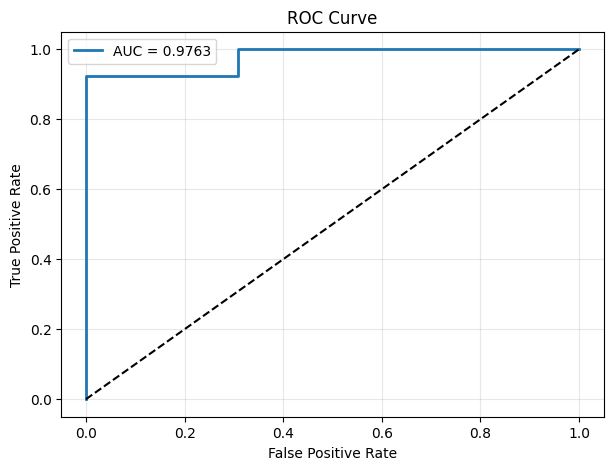

In [76]:
fpr, tpr, thresholds = roc_curve(y_val, y_pred_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, linewidth=2, label=f'AUC = {auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()




 # 🎯 Optimal Threshold Suggestion -->

In [77]:
# Youden's J statistic = maximize sensitivity + specificity − 1
J_scores = tpr - fpr
best_idx = np.argmax(J_scores)
best_threshold = thresholds[best_idx]

print(f"\nBest threshold (Youden J): {best_threshold:.3f}")

# Compare performance at optimal threshold
y_pred_opt = (y_pred_proba >= best_threshold).astype(int)

print("\n--- Report with Optimal Threshold ---")
print(classification_report(y_val, y_pred_opt))




Best threshold (Youden J): 0.772

--- Report with Optimal Threshold ---
              precision    recall  f1-score   support

           0       0.93      1.00      0.96        13
           1       1.00      0.92      0.96        13

    accuracy                           0.96        26
   macro avg       0.96      0.96      0.96        26
weighted avg       0.96      0.96      0.96        26



# 📉 Training Curves

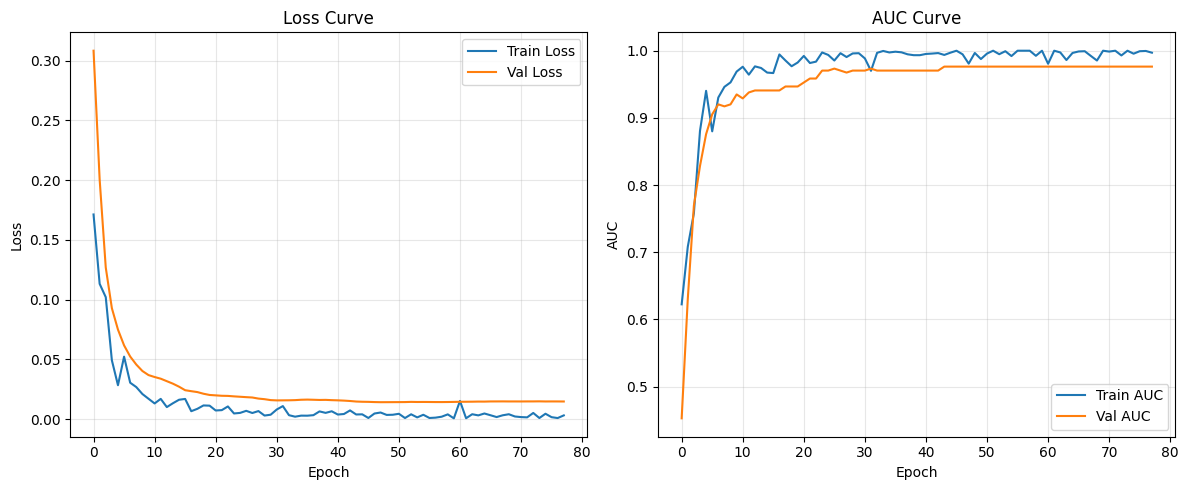

In [78]:

plt.figure(figsize=(12,5))

# Loss curve
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.grid(alpha=0.3)

# AUC curve
plt.subplot(1,2,2)
plt.plot(history.history['AUC'], label='Train AUC')
plt.plot(history.history['val_AUC'], label='Val AUC')
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("AUC Curve")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Prediction 

In [79]:
preds = model.predict(X_test_prunned).flatten()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step 


In [81]:
submission = pd.DataFrame({
    "ID": range(len(preds)),
    "Target": preds
})

submission.to_csv("submission.csv", index=False)
print("✓ submission.csv généré")

✓ submission.csv généré
